<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/L05-Regresion/notebooks/L05_1_RegresionST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.formula.api as smf
import statsmodels.graphics.tsaplots as smt
import seaborn as sns

In [2]:
# Subir archivo pasajeros.csv
from google.colab import files
files.upload()

Saving pasajeros.csv to pasajeros (6).csv


{'pasajeros (6).csv': b'Year,Month,TOTAL\r\n2010,1,"57,895,059"\r\n2010,2,"53,134,779"\r\n2010,3,"67,703,397"\r\n2010,4,"64,896,774"\r\n2010,5,"67,223,086"\r\n2010,6,"71,096,629"\r\n2010,7,"75,169,345"\r\n2010,8,"72,688,674"\r\n2010,9,"62,903,857"\r\n2010,10,"67,700,757"\r\n2010,11,"63,071,833"\r\n2010,12,"63,993,866"\r\n2011,1,"58,973,763"\r\n2011,2,"54,602,428"\r\n2011,3,"69,123,133"\r\n2011,4,"66,395,631"\r\n2011,5,"69,917,366"\r\n2011,6,"72,593,371"\r\n2011,7,"76,934,242"\r\n2011,8,"73,157,273"\r\n2011,9,"64,203,054"\r\n2011,10,"67,324,276"\r\n2011,11,"63,816,216"\r\n2011,12,"65,094,040"\r\n2012,1,"60,287,641"\r\n2012,2,"58,138,329"\r\n2012,3,"70,588,068"\r\n2012,4,"67,686,947"\r\n2012,5,"70,040,634"\r\n2012,6,"73,485,628"\r\n2012,7,"76,657,857"\r\n2012,8,"75,262,947"\r\n2012,9,"63,926,218"\r\n2012,10,"67,177,431"\r\n2012,11,"64,608,329"\r\n2012,12,"65,263,336"\r\n2013,1,"61,585,678"\r\n2013,2,"57,777,742"\r\n2013,3,"71,752,871"\r\n2013,4,"67,530,194"\r\n2013,5,"71,916,594"\r\n2013

In [3]:
# Leer el archivo motororg.dat
df = pd.read_csv('/content/pasajeros.csv')
df.head()

,Year,Month,TOTAL
0,2010,1,"57,895,059"
1,2010,2,"53,134,779"
2,2010,3,"67,703,397"
3,2010,4,"64,896,774"
4,2010,5,"67,223,086"


In [4]:
# Limpiar columpa de total para convertirla en numérica y luego ver datos en millones
df['TOTAL'] = df['TOTAL'].str.replace(',', '', regex=True).astype(float) / 1_000_000

df['Fecha'] = pd.period_range(start='2010-01', periods=len(df), freq='M')
df = df.set_index('Fecha')
df.index = df.index.to_timestamp()
df.head()

,Year,Month,TOTAL
Fecha,,,
2010-01-01,2010,1,57.895059
2010-02-01,2010,2,53.134779
2010-03-01,2010,3,67.703397
2010-04-01,2010,4,64.896774
2010-05-01,2010,5,67.223086


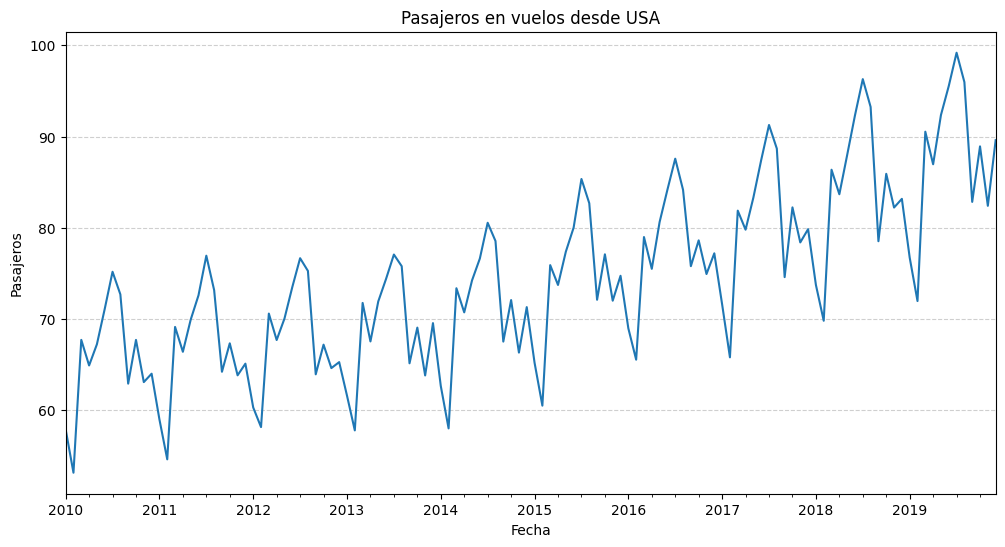

In [5]:
# Gráfico inicial
plt.figure(figsize=(12, 6))
df['TOTAL'].plot()

# Etiquetas
plt.title('Pasajeros en vuelos desde USA')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Modelo usando tendencia

In [6]:
# Crear columna de tendencia para la regresión lineal
df['tend'] = np.arange(len(df))
df

,Year,Month,TOTAL,tend
Fecha,,,,
2010-01-01,2010,1,57.895059,0
2010-02-01,2010,2,53.134779,1
2010-03-01,2010,3,67.703397,2
2010-04-01,2010,4,64.896774,3
2010-05-01,2010,5,67.223086,4
...,...,...,...,...
2019-08-01,2019,8,95.968379,115
2019-09-01,2019,9,82.833675,116
2019-10-01,2019,10,88.919490,117


In [7]:
# Ajustar un modelo de regresión lineal
reg_tend = smf.ols('TOTAL ~ tend', data=df).fit()

# Imprimir tabla resumen
print(reg_tend.summary())

                            OLS Regression Results                            
Dep. Variable:                  TOTAL   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.568
Method:                 Least Squares   F-statistic:                     157.2
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.94e-23
Time:                        07:43:41   Log-Likelihood:                -393.42
No. Observations:                 120   AIC:                             790.8
Df Residuals:                     118   BIC:                             796.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     61.7670      1.175     52.575      0.0

**Sección de Residuales**

- Test Omnibus: Normalidad con base en Asimetría y Curtosis
  - Prob(Omnibus) < $\alpha$: Residuales no siguen una distribución normal
  - Prob(Omnibus) > $\alpha$: Residuales siguen una distribución normal

- Skew (Sesgo) De los RESIDUALES:
  - < 0 *(Sesgo negativo)*: Cola del lado izquierdo
  - > 0 *(Sesgo negativo)*: Cola del lado derecho

- Kurtosis (Curtosis) de los RESIDUALES:
  - = 3: Curva de distribución normal
  - > 3: Curva más puntiaguda
  - < 3 Curva más aplanada

- Durbin-Watson: Valores cercanos a 2 sugieren poca o ninguna autocorrelación (1.5 a 2.5 por ejemplo)

- JB: Prueba de normalidad
  - Prob(JB) < $\alpha$: Residuales no siguen una distribución normal
  - Prob(JB) > $\alpha$: Residuales siguen una distribución normal

- Cond. No.: Multicolinealidad

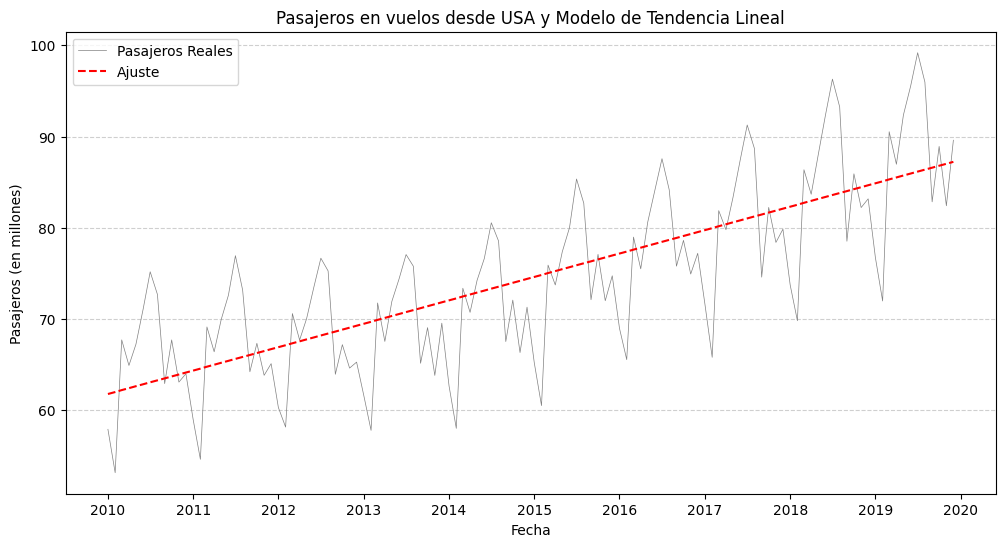

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['TOTAL'], label='Pasajeros Reales', color = 'gray', lw = .5)
plt.plot(df.index, reg_tend.predict(df['tend']), label='Ajuste', color='red', linestyle='--')

plt.title('Pasajeros en vuelos desde USA y Modelo de Tendencia Lineal')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros (en millones)')
plt.legend()
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

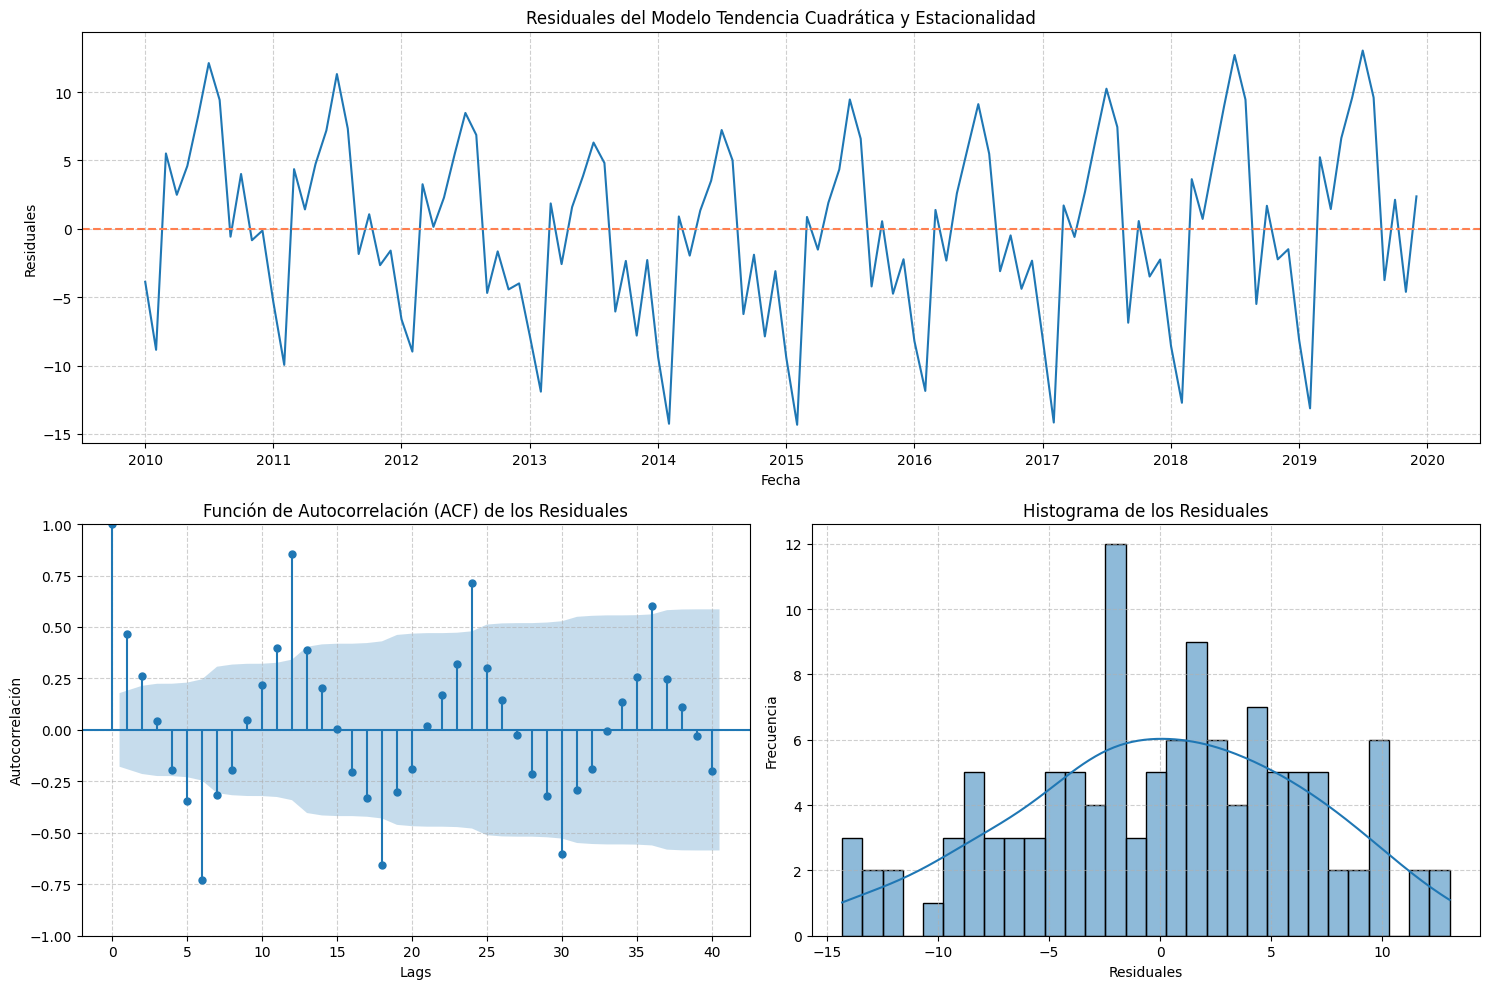

In [9]:
# Gráficos de Residuales
modelo = reg_tend
nombre = 'Tendencia Cuadrática y Estacionalidad'

residuales = modelo.resid

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Gráfico 1: Residuales como serie de tiempo (ocupando ambas columnas de la fila superior)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, residuales)

# Gráfico 1: Formato
ax1.axhline(0, color='coral', linestyle='--')
ax1.set_title('Residuales del Modelo ' + nombre)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Residuales')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: ACF de los residuales (parte inferior izquierda)
ax2 = fig.add_subplot(gs[1, 0])
smt.plot_acf(residuales, lags=40, ax=ax2)

# Gráfico 2: Formato
ax2.set_title('Función de Autocorrelación (ACF) de los Residuales')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelación')
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Histograma de los residuales (parte inferior derecha)
ax3 = fig.add_subplot(gs[1, 1])
sns.histplot(residuales, bins=30, kde=True, ax=ax3, edgecolor='black')

# Gráfico 3: Formato
ax3.set_title('Histograma de los Residuales')
ax3.set_xlabel('Residuales')
ax3.set_ylabel('Frecuencia')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Modelo usando tendencia cuadrática

In [10]:
df['tend_sq'] = df['tend']**2
df

,Year,Month,TOTAL,tend,tend_sq
Fecha,,,,,
2010-01-01,2010,1,57.895059,0,0
2010-02-01,2010,2,53.134779,1,1
2010-03-01,2010,3,67.703397,2,4
2010-04-01,2010,4,64.896774,3,9
2010-05-01,2010,5,67.223086,4,16
...,...,...,...,...,...
2019-08-01,2019,8,95.968379,115,13225
2019-09-01,2019,9,82.833675,116,13456
2019-10-01,2019,10,88.919490,117,13689


In [11]:
# Ajustar un modelo de regresión lineal con tendencia cuadrática
reg_tend_sq = smf.ols('TOTAL ~ tend + tend_sq', data=df).fit()

# Imprimir tabla resumen
print(reg_tend_sq.summary())

                            OLS Regression Results                            
Dep. Variable:                  TOTAL   R-squared:                       0.593
Model:                            OLS   Adj. R-squared:                  0.586
Method:                 Least Squares   F-statistic:                     85.19
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.47e-23
Time:                        07:43:43   Log-Likelihood:                -390.30
No. Observations:                 120   AIC:                             786.6
Df Residuals:                     117   BIC:                             795.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     64.9177      1.707     38.038      0.0

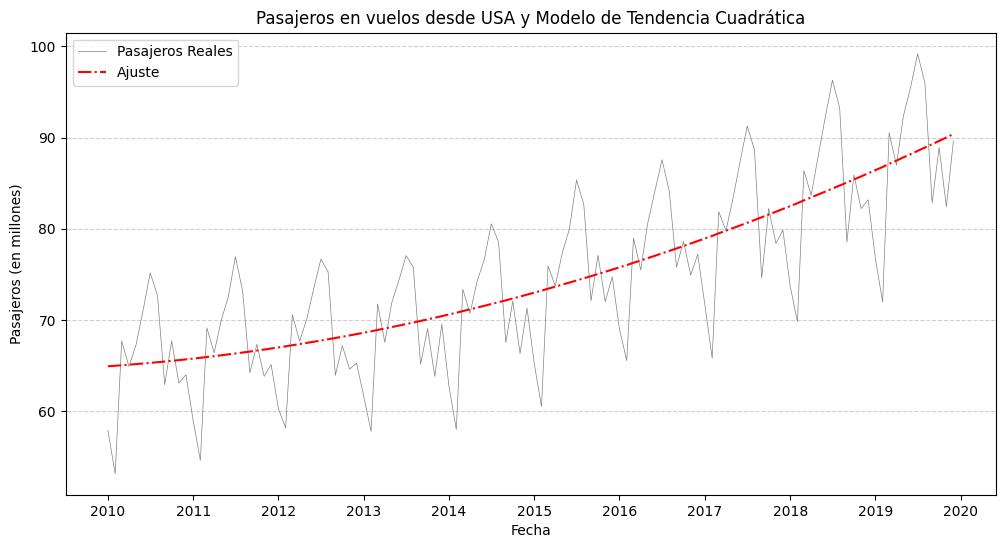

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['TOTAL'], label='Pasajeros Reales', color = 'gray', lw = .5)
plt.plot(df.index, reg_tend_sq.predict(df[['tend', 'tend_sq']]), label='Ajuste', color='red', linestyle='-.')

plt.title('Pasajeros en vuelos desde USA y Modelo de Tendencia Cuadrática')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros (en millones)')
plt.legend()
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

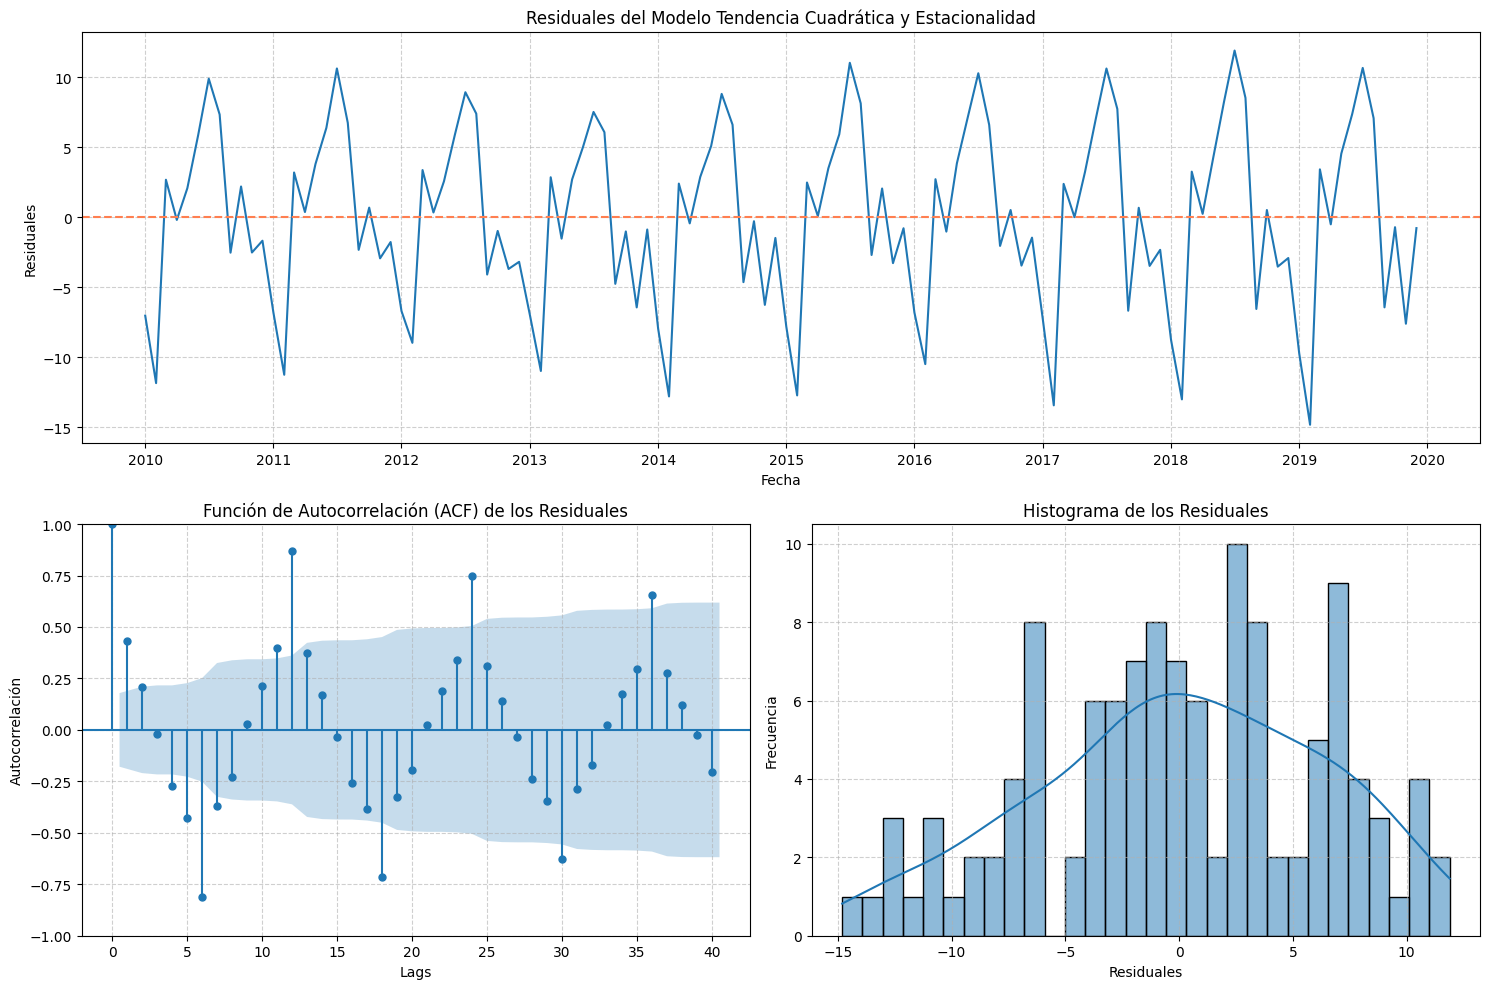

In [13]:
# Gráficos de Residuales
modelo = reg_tend_sq
nombre = 'Tendencia Cuadrática y Estacionalidad'

residuales = modelo.resid

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Gráfico 1: Residuales como serie de tiempo (ocupando ambas columnas de la fila superior)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, residuales)

# Gráfico 1: Formato
ax1.axhline(0, color='coral', linestyle='--')
ax1.set_title('Residuales del Modelo ' + nombre)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Residuales')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: ACF de los residuales (parte inferior izquierda)
ax2 = fig.add_subplot(gs[1, 0])
smt.plot_acf(residuales, lags=40, ax=ax2)

# Gráfico 2: Formato
ax2.set_title('Función de Autocorrelación (ACF) de los Residuales')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelación')
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Histograma de los residuales (parte inferior derecha)
ax3 = fig.add_subplot(gs[1, 1])
sns.histplot(residuales, bins=30, kde=True, ax=ax3, edgecolor='black')

# Gráfico 3: Formato
ax3.set_title('Histograma de los Residuales')
ax3.set_xlabel('Residuales')
ax3.set_ylabel('Frecuencia')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Modelo de tendencia más estacionalidad

In [14]:
df['estacion'] = df.index.month
df

,Year,Month,TOTAL,tend,tend_sq,estacion
Fecha,,,,,,
2010-01-01,2010,1,57.895059,0,0,1
2010-02-01,2010,2,53.134779,1,1,2
2010-03-01,2010,3,67.703397,2,4,3
2010-04-01,2010,4,64.896774,3,9,4
2010-05-01,2010,5,67.223086,4,16,5
...,...,...,...,...,...,...
2019-08-01,2019,8,95.968379,115,13225,8
2019-09-01,2019,9,82.833675,116,13456,9
2019-10-01,2019,10,88.919490,117,13689,10


In [15]:
# Ajustar un modelo de regresión lineal con tendencia y estacionalidad
reg_tend_est = smf.ols('TOTAL ~ tend + C(estacion)', data=df).fit()

# Imprimir tabla resumen
print(reg_tend_est.summary())

                            OLS Regression Results                            
Dep. Variable:                  TOTAL   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     239.6
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.94e-71
Time:                        07:43:44   Log-Likelihood:                -244.57
No. Observations:                 120   AIC:                             515.1
Df Residuals:                     107   BIC:                             551.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            54.4195      0.68

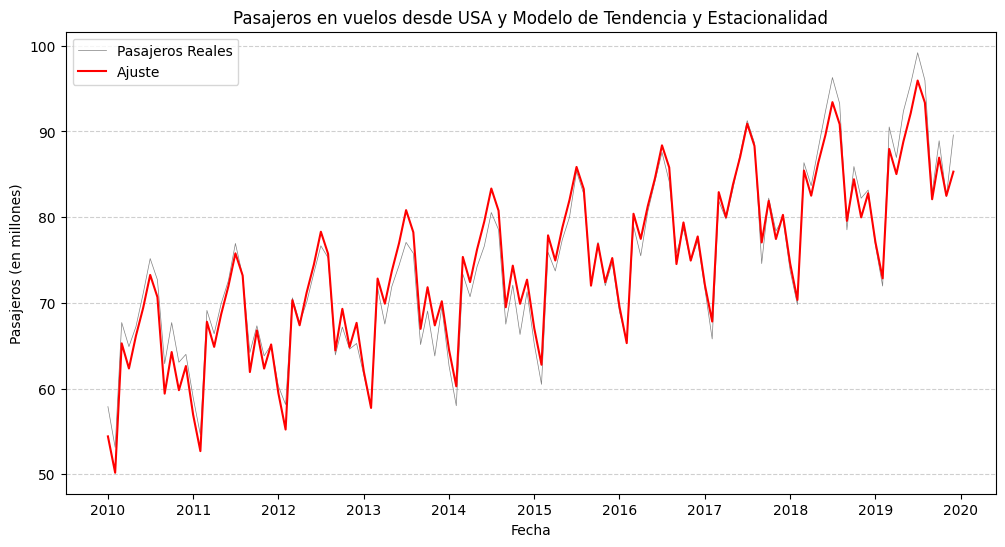

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['TOTAL'], label='Pasajeros Reales', color = 'gray', lw = .5)
plt.plot(df.index, reg_tend_est.predict(df[['tend', 'estacion']]), label='Ajuste', color='red')

plt.title('Pasajeros en vuelos desde USA y Modelo de Tendencia y Estacionalidad')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros (en millones)')
plt.legend()
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

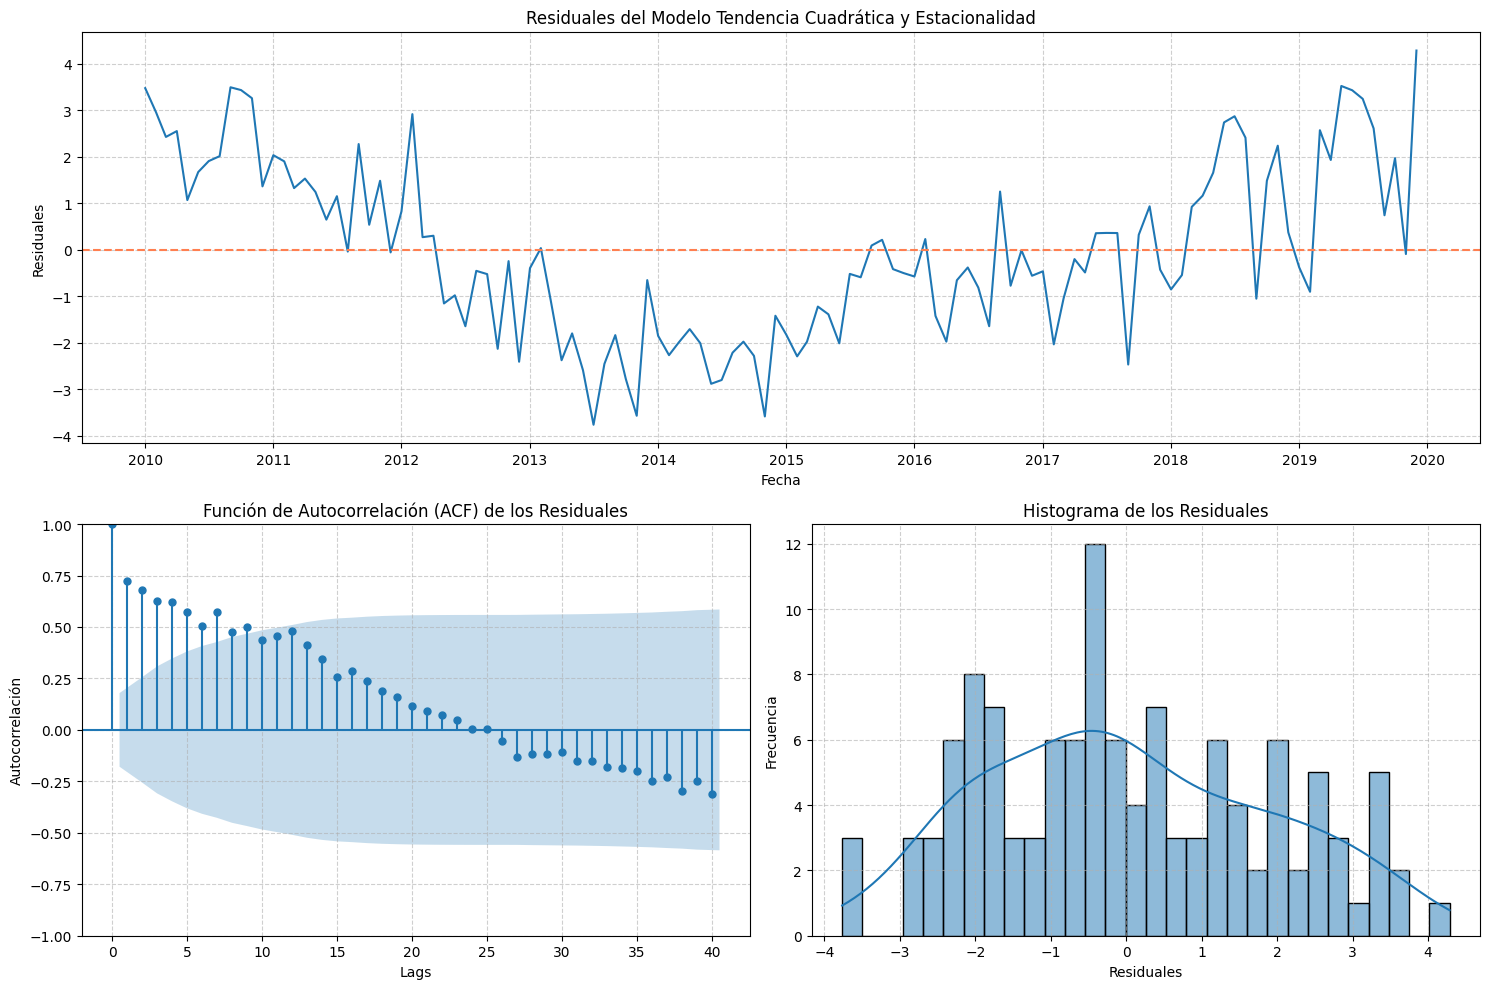

In [17]:
# Gráficos de Residuales
modelo = reg_tend_est
nombre = 'Tendencia Cuadrática y Estacionalidad'

residuales = modelo.resid

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Gráfico 1: Residuales como serie de tiempo (ocupando ambas columnas de la fila superior)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, residuales)

# Gráfico 1: Formato
ax1.axhline(0, color='coral', linestyle='--')
ax1.set_title('Residuales del Modelo ' + nombre)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Residuales')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: ACF de los residuales (parte inferior izquierda)
ax2 = fig.add_subplot(gs[1, 0])
smt.plot_acf(residuales, lags=40, ax=ax2)

# Gráfico 2: Formato
ax2.set_title('Función de Autocorrelación (ACF) de los Residuales')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelación')
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Histograma de los residuales (parte inferior derecha)
ax3 = fig.add_subplot(gs[1, 1])
sns.histplot(residuales, bins=30, kde=True, ax=ax3, edgecolor='black')

# Gráfico 3: Formato
ax3.set_title('Histograma de los Residuales')
ax3.set_xlabel('Residuales')
ax3.set_ylabel('Frecuencia')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [18]:
# Ajustar un modelo de regresión lineal con tendencia y estacionalidad, usando el mes 12 como referencia
reg_tend_est_ref12 = smf.ols('TOTAL ~ tend + C(estacion, Treatment(reference=12))', data=df).fit()

# Imprimir tabla resumen
print(reg_tend_est_ref12.summary())

                            OLS Regression Results                            
Dep. Variable:                  TOTAL   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     239.6
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           1.94e-71
Time:                        07:43:46   Log-Likelihood:                -244.57
No. Observations:                 120   AIC:                             515.1
Df Residuals:                     107   BIC:                             551.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

## Modelo Tendencia Transformada y Estacionalidad


In [19]:
# Ajustar un modelo de regresión lineal con tendencia, tendencia cuadrática y estacionalidad
reg_tend_sq_est = smf.ols('TOTAL ~ tend + tend_sq + C(estacion)', data=df).fit()

# Imprimir tabla resumen
print(reg_tend_sq_est.summary())

                            OLS Regression Results                            
Dep. Variable:                  TOTAL   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     628.1
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           7.03e-94
Time:                        07:43:46   Log-Likelihood:                -182.80
No. Observations:                 120   AIC:                             393.6
Df Residuals:                     106   BIC:                             432.6
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            57.6419      0.47

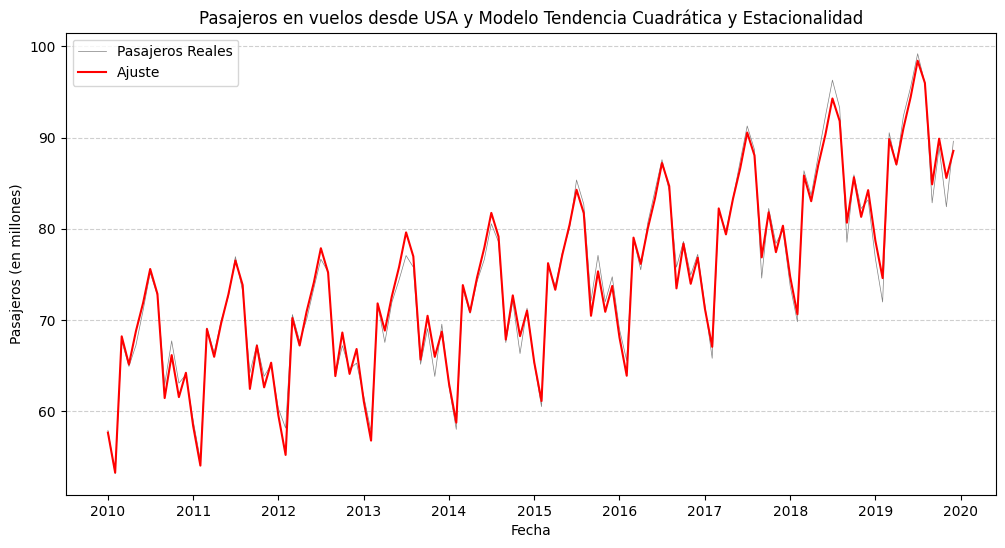

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['TOTAL'], label='Pasajeros Reales', color = 'gray', lw = .5)
plt.plot(df.index, reg_tend_sq_est.predict(df[['tend', 'tend_sq', 'estacion']]), label='Ajuste', color='red')

plt.title('Pasajeros en vuelos desde USA y Modelo Tendencia Cuadrática y Estacionalidad')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros (en millones)')
plt.legend()
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

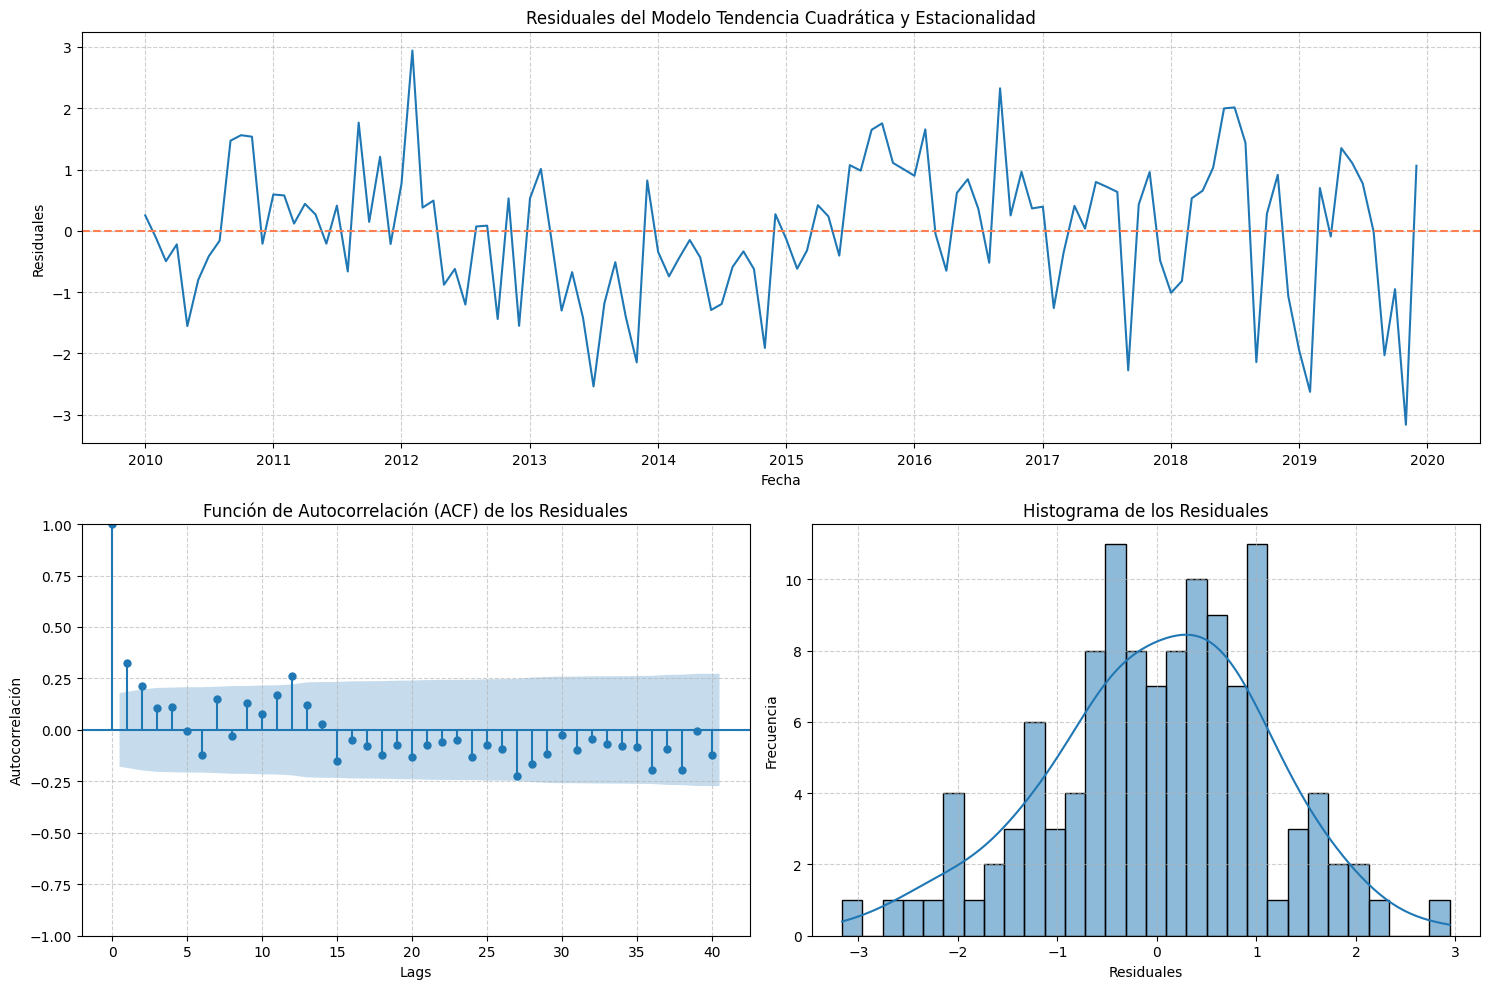

In [21]:
# Gráficos de Residuales
modelo = reg_tend_sq_est
nombre = 'Tendencia Cuadrática y Estacionalidad'

residuales = modelo.resid

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Gráfico 1: Residuales como serie de tiempo (ocupando ambas columnas de la fila superior)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, residuales)

# Gráfico 1: Formato
ax1.axhline(0, color='coral', linestyle='--')
ax1.set_title('Residuales del Modelo ' + nombre)
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Residuales')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: ACF de los residuales (parte inferior izquierda)
ax2 = fig.add_subplot(gs[1, 0])
smt.plot_acf(residuales, lags=40, ax=ax2)

# Gráfico 2: Formato
ax2.set_title('Función de Autocorrelación (ACF) de los Residuales')
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelación')
ax2.grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Histograma de los residuales (parte inferior derecha)
ax3 = fig.add_subplot(gs[1, 1])
sns.histplot(residuales, bins=30, kde=True, ax=ax3, edgecolor='black')

# Gráfico 3: Formato
ax3.set_title('Histograma de los Residuales')
ax3.set_xlabel('Residuales')
ax3.set_ylabel('Frecuencia')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

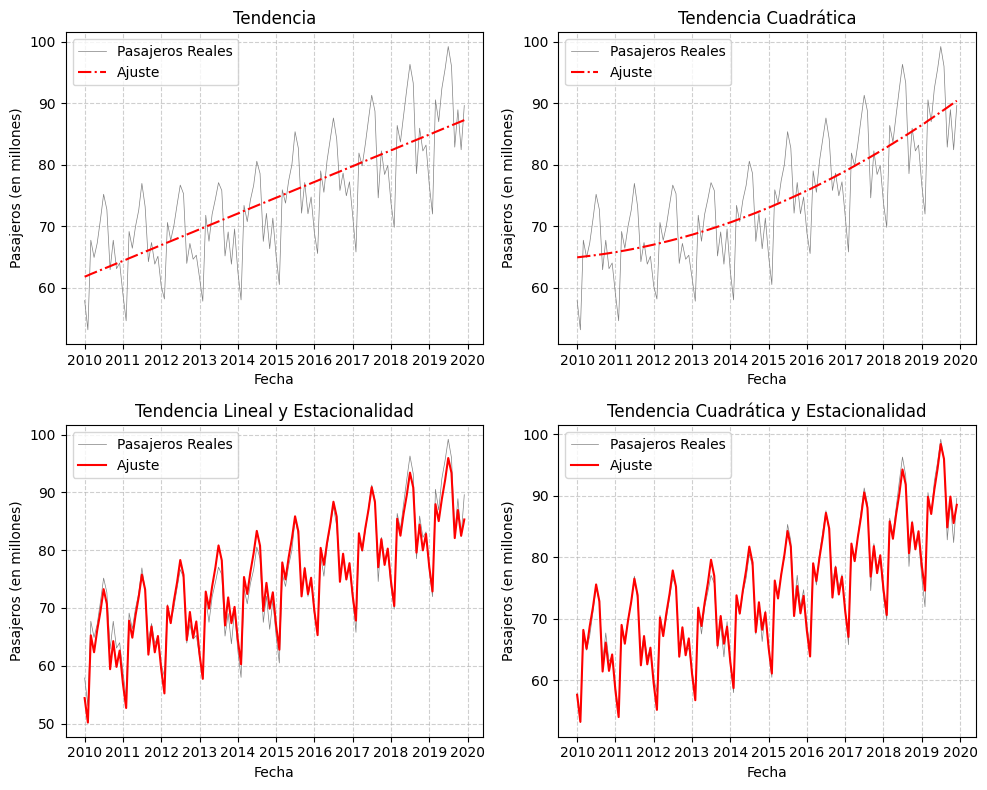

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Gráfico 1: Modelo reg_tend
axes[0, 0].plot(df.index, df['TOTAL'], label='Pasajeros Reales', color = 'gray', lw = .5)
axes[0, 0].plot(df.index, reg_tend.predict(df['tend']), label='Ajuste', color='red', linestyle='-.')
axes[0, 0].set_title('Tendencia')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Pasajeros (en millones)')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Modelo reg_tend_sq
axes[0, 1].plot(df.index, df['TOTAL'], label='Pasajeros Reales', color = 'gray', lw = .5)
axes[0, 1].plot(df.index, reg_tend_sq.predict(df[['tend', 'tend_sq']]), label='Ajuste', color='red', linestyle='-.')
axes[0, 1].set_title('Tendencia Cuadrática')
axes[0, 1].set_xlabel('Fecha')
axes[0, 1].set_ylabel('Pasajeros (en millones)')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Gráfico 3: Modelo reg_tend_est
axes[1, 0].plot(df.index, df['TOTAL'], label='Pasajeros Reales', color = 'gray', lw = .5)
axes[1, 0].plot(df.index, reg_tend_est.predict(df[['tend', 'estacion']]), label='Ajuste', color='red')
axes[1, 0].set_title('Tendencia Lineal y Estacionalidad')
axes[1, 0].set_xlabel('Fecha')
axes[1, 0].set_ylabel('Pasajeros (en millones)')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.6)

# Gráfico 4: Modelo reg_tend_sq_est
axes[1, 1].plot(df.index, df['TOTAL'], label='Pasajeros Reales', color = 'gray', lw = .5)
axes[1, 1].plot(df.index, reg_tend_sq_est.predict(df[['tend', 'tend_sq', 'estacion']]), label='Ajuste', color='red')
axes[1, 1].set_title('Tendencia Cuadrática y Estacionalidad')
axes[1, 1].set_xlabel('Fecha')
axes[1, 1].set_ylabel('Pasajeros (en millones)')
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [23]:
nomModelos = ['Tendencia Lineal', 'Tendencia Cuadrática', 'Tend + Estacionalidad', 'Tend Cuadrática + Estacionalidad']
modelos = [reg_tend, reg_tend_sq, reg_tend_est, reg_tend_sq_est]

metrics = []

for i, modelo in enumerate(modelos):
    r_squared = modelo.rsquared
    adj_r_squared = modelo.rsquared_adj
    aic = modelo.aic
    bic = modelo.bic

    metrics.append({
        'Modelo': nomModelos[i],
        'R-squared': r_squared,
        'R-squared Ajustado': adj_r_squared,
        'AIC': aic,
        'BIC': bic
    })

comparative_df = pd.DataFrame(metrics)
comparative_df = comparative_df.set_index('Modelo')
comparative_df

,R-squared,R-squared Ajustado,AIC,BIC
Modelo,,,,
Tendencia Lineal,0.571176,0.567542,790.841655,796.416639
Tendencia Cuadrática,0.592885,0.585925,786.607547,794.970022
Tend + Estacionalidad,0.964118,0.960094,515.144469,551.381861
Tend Cuadrática + Estacionalidad,0.987184,0.985612,393.602408,432.627292
